In [1]:
import pandas as pd

# dataset load karo
df = pd.read_csv("../data/insurance.csv")

# first 5 rows dekho
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [3]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [4]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [5]:
# categorical columns ko convert karna
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})
df['region'] = df['region'].astype('category').cat.codes

df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,1,27.9,0,1,3,16884.92
1,18,0,33.8,1,0,2,1725.55
2,28,0,33.0,3,0,2,4449.46
3,33,0,22.7,0,0,1,21984.47
4,32,0,28.9,0,0,1,3866.86


In [6]:
X = df.drop('charges', axis=1)  # input features
y = df['charges']               # output (premium)

KeyError: "['charges'] not found in axis"

In [7]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses'], dtype='object')

In [8]:
X = df.drop('expenses', axis=1)
y = df['expenses']

In [9]:
print(X.shape)

(1338, 6)


In [10]:
print(y.shape)

(1338,)


In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

NameError: name 'X_train' is not defined

In [12]:
X = df.drop('expenses', axis=1)
y = df['expenses']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

TypeError: got an unexpected keyword argument 'squared'

In [18]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 5799.920265829358
R2 Score: 0.7833214205203847


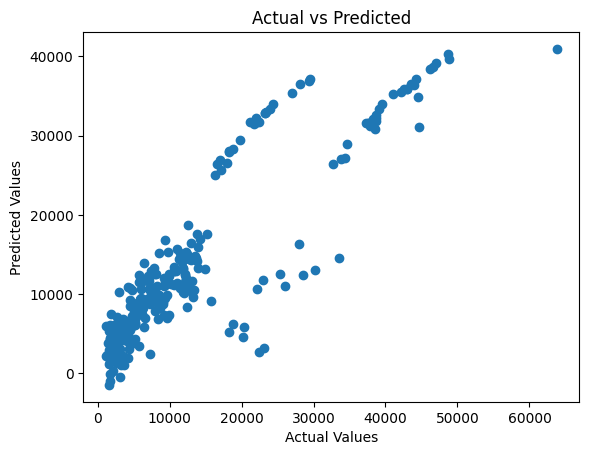

In [19]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

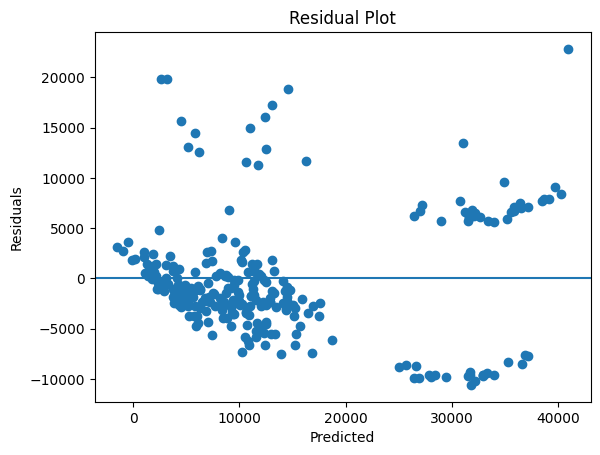

In [20]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.axhline(y=0)
plt.show()

In [21]:
import pandas as pd

coefficients = pd.DataFrame({
    'Feature': df.drop('expenses', axis=1).columns,
    'Importance': model.coef_
})

coefficients = coefficients.sort_values(by='Importance', ascending=False)

print(coefficients)

    Feature   Importance
4    smoker  9556.783355
0       age  3615.855916
2       bmi  2029.222126
3  children   517.114360
1       sex     9.349643
5    region  -302.319105


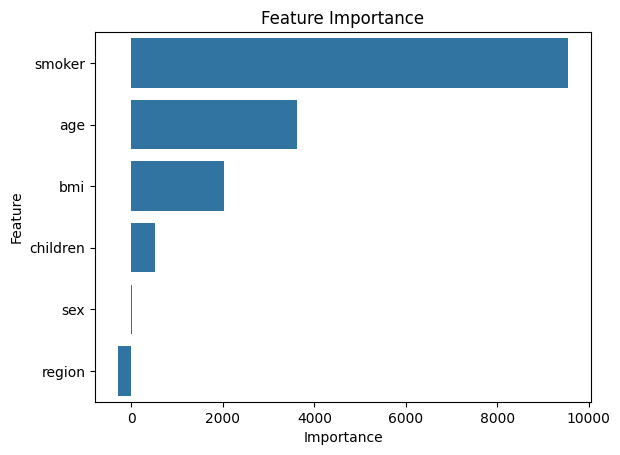

In [22]:
import seaborn as sns

sns.barplot(x='Importance', y='Feature', data=coefficients)
plt.title("Feature Importance")
plt.show()

In [23]:
import pickle

with open("../models/model.pkl", "wb") as f:
    pickle.dump(model, f)

In [24]:
import pickle

# model save
with open("../models/model.pkl", "wb") as f:
    pickle.dump(model, f)

# scaler save
with open("../models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [25]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import r2_score
print("RF R2:", r2_score(y_test, y_pred_rf))

RF R2: 0.8664322711480837
